In [1]:
import pandas as pd
import pickle

with open('./data/monthly_returns.pkl', 'rb') as f:
    ret = pickle.load(f)

ret_baseline = pd.read_csv('./output/baseline.csv', parse_dates=[0], index_col=0)
ret_twostage = pd.read_csv('./output/twostage.csv', parse_dates=[0], index_col=0)

C:\Users\jason\AppData\Local\Temp\ipykernel_37996\4146288374.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  ret = pickle.load(f)



分组回测Sharpe比率统计
               Pre     In   Post  Total
Portfolio                              
G1           1.019 -0.434 -0.380 -0.038
G2           1.322  0.052  0.037  0.396
G3           1.557  0.257  0.190  0.595
G4           1.696  0.427  0.266  0.730
G5           2.010  0.647  0.141  0.894
Hedge G5-G1  2.752  3.154  1.381  2.606


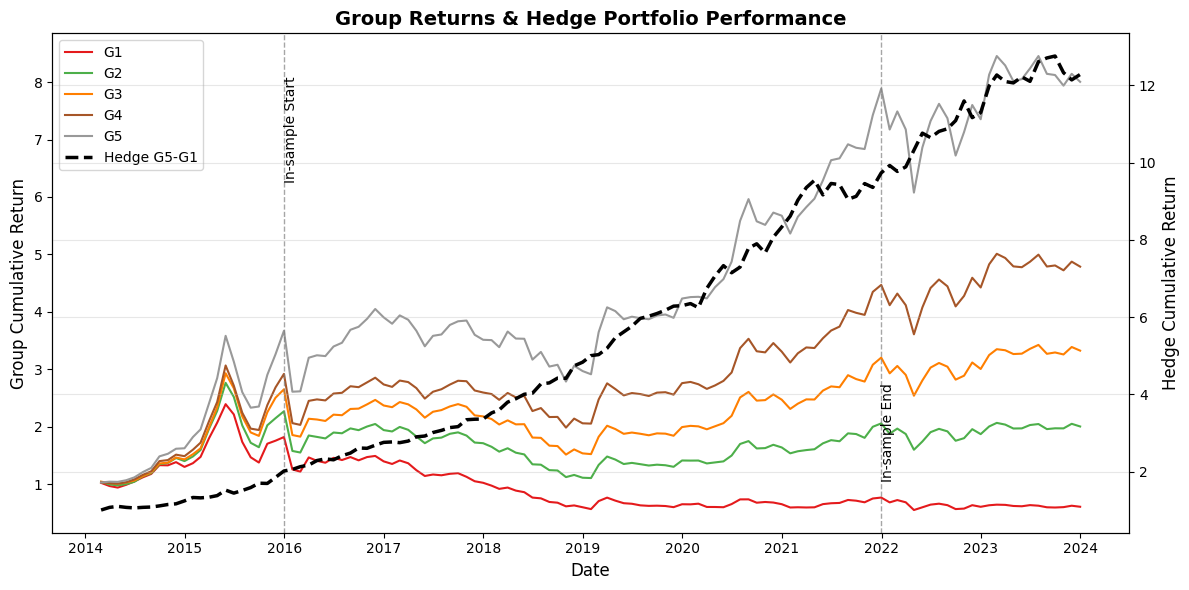


分组回测Sharpe比率统计
               Pre     In   Post  Total
Portfolio                              
G1           0.868 -0.454 -0.445 -0.099
G2           1.240  0.052 -0.178  0.337
G3           1.592  0.304  0.198  0.629
G4           1.787  0.363  0.421  0.741
G5           2.154  0.719  0.299  0.994
Hedge G5-G1  3.527  2.950  1.625  2.733


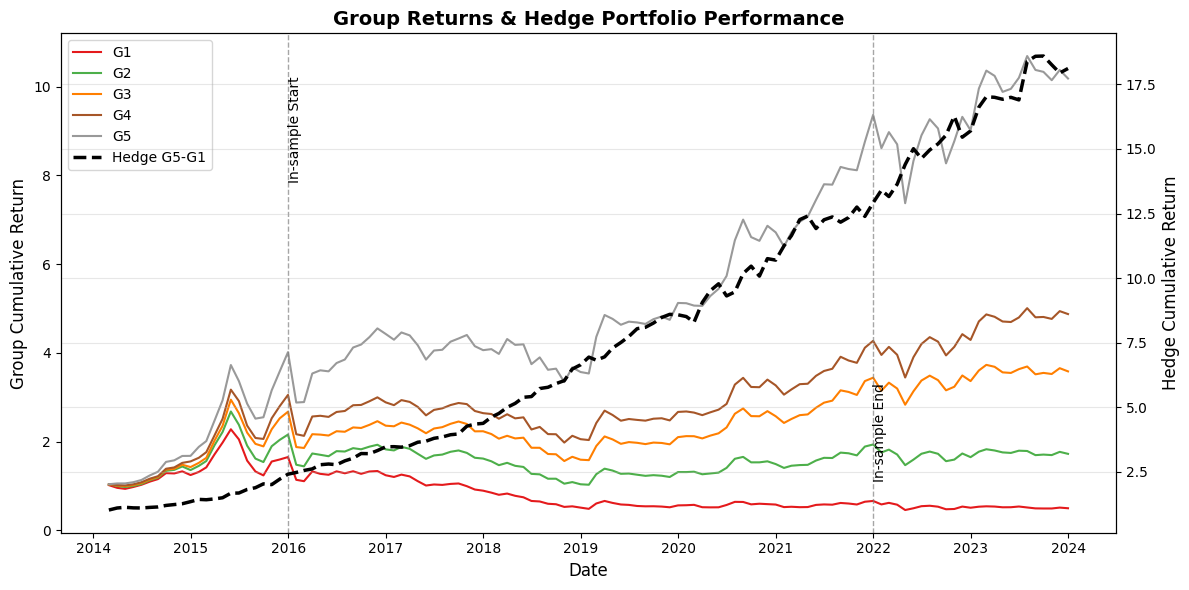

In [2]:
from tools import *
pre_sample = ('2014-01-01', '2015-12-31')
in_sample = ('2016-01-01', '2021-12-31')
post_sample = ('2022-01-01', '2023-12-31')
all_sample = ('2014-01-01', '2023-12-31')
ret = ret.loc[all_sample[0]:all_sample[1]]
baseline_ret, _ = group_analysis(ret_baseline, ret, in_sample)
twostage_ret, _ = group_analysis(ret_twostage, ret, in_sample)

In [3]:
diff_ret = twostage_ret - baseline_ret
ff5 = pd.read_csv('./data/FF5.csv', parse_dates=[0], index_col=0)

common_dates = diff_ret.index.intersection(ff5.index)
y = diff_ret.loc[common_dates]
X = ff5.loc[common_dates]

X = sm.add_constant(X)
# NW adjusted
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': int(4*(len(X)/100)**(2/9))})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     8.722
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           5.08e-07
Time:                        13:32:37   Log-Likelihood:                 372.44
No. Observations:                 119   AIC:                            -732.9
Df Residuals:                     113   BIC:                            -716.2
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      2.761      0.0

In [50]:
features_path = './data/features'

with open(f'./data/monthly_returns.pkl', 'rb') as f:
    ret = pickle.load(f).loc[all_sample[0]:all_sample[1]]
    f_mkt = ret.mean(axis=1)
    
with open(f'{features_path}/mcap.pkl', 'rb') as f:
    df = pickle.load(f).loc[all_sample[0]:all_sample[1]]
    df.fillna(df.median(axis=1), axis=0)
    mcap = xs_zscore(df)
    f_size, _ = group_analysis(mcap, ret, in_sample, draw=False)



# 盈利
with open(f'{features_path}/operating_profit_to_book_value_ttm.pkl', 'rb') as f:
    df = pickle.load(f).loc[all_sample[0]:all_sample[1]]
    df.fillna(df.median(axis=1), axis=0)
    roe = xs_zscore(df)
    f_roe, _ = group_analysis(roe, ret, in_sample, draw=False)
    f_roe_sft, _ = group_analysis(roe.shift(-1), ret, in_sample, draw=False)

with open(f'{features_path}/accrual_to_net_profit_ttm.pkl', 'rb') as f:
    df = pickle.load(f).loc[all_sample[0]:all_sample[1]]
    df.fillna(df.median(axis=1), axis=0)
    atn = xs_zscore(df)
    f_atn, _ = group_analysis(atn, ret, in_sample, draw=False)
    f_atn_sft, _ = group_analysis(atn.shift(-1), ret, in_sample, draw=False)

with open(f'{features_path}/capital_gain_overhang_252.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    cap_gain = xs_zscore(df)
    f_cap_gain, _ = group_analysis(cap_gain, ret, in_sample, draw=False)
    f_cap_gain_sft, _ = group_analysis(cap_gain.shift(-1), ret, in_sample, draw=False)

f_earn = (f_roe + f_atn + f_cap_gain) / 3
f_earn_sft = (f_roe_sft + f_atn_sft + f_cap_gain_sft) / 3


# 估值
with open(f'{features_path}/book_value_mrq.pkl', 'rb') as f:
    df = pickle.load(f).loc[all_sample[0]:all_sample[1]]
    df.fillna(df.median(axis=1), axis=0)
    book = xs_zscore(df)
    f_book, _ = group_analysis(book, ret, in_sample, draw=False)
    f_book_sft, _ = group_analysis(book.shift(-1), ret, in_sample, draw=False)
    f_bm, _ = group_analysis(book / mcap, ret, in_sample, draw=False)
    f_bm_sft, _ = group_analysis(book.shift(-1) / mcap, ret, in_sample, draw=False)

with open(f'{features_path}/basic_eps_mra.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    eps = xs_zscore(df)
    f_eps, _ = group_analysis(eps, ret, in_sample, draw=False)
    f_eps_sft, _ = group_analysis(eps.shift(-1), ret, in_sample, draw=False)

f_value = (f_bm + f_eps) / 2
f_value_sft = (f_bm_sft + f_eps_sft) / 2

# 投资/增长
with open(f'{features_path}/asset_growth_mrq.pkl', 'rb') as f:
    df = pickle.load(f).loc[all_sample[0]:all_sample[1]]
    df.fillna(df.median(axis=1), axis=0)
    ast_grth = xs_zscore(df)
    f_ast_grth, _ = group_analysis(ast_grth, ret, in_sample, draw=False)
    f_ast_grth_sft, _ = group_analysis(ast_grth.shift(-1), ret, in_sample, draw=False)

with open(f'{features_path}/change_in_net_operating_assets.pkl', 'rb') as f:
    df = pickle.load(f)
    df.fillna(df.median(axis=1), axis=0)
    op_ast_cng = xs_zscore(df)
    f_op_ast_cng, _ = group_analysis(op_ast_cng, ret, in_sample, draw=False)
    f_op_ast_cng_sft, _ = group_analysis(op_ast_cng.shift(-1), ret, in_sample, draw=False)

f_gwth = (f_ast_grth + f_op_ast_cng) / 2
f_gwth_sft = (f_ast_grth_sft + f_op_ast_cng_sft) / 2


C:\Users\jason\AppData\Local\Temp\ipykernel_37996\525268689.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  ret = pickle.load(f).loc[all_sample[0]:all_sample[1]]
C:\Users\jason\AppData\Local\Temp\ipykernel_37996\525268689.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of

In [51]:
import statsmodels.api as sm
f_unsft =  pd.DataFrame({
    'HML': f_value,
    'RMW': f_earn,
    'CMA': f_gwth,

    # control
    'MKT': f_mkt,
    'SMB': f_size,

})

f_sft =  pd.DataFrame({
    'HML_sft': f_value_sft,
    'RMW_sft': f_earn_sft,
    'CMA_sft': f_gwth_sft,

    # control
    'MKT': f_mkt,
    'SMB': f_size,

})


In [52]:
common_dates = diff_ret.index.intersection(f_unsft.index)
y = diff_ret.loc[common_dates]
X = f_unsft.loc[common_dates]

X = sm.add_constant(X)
# NW adjusted
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': int(4*(len(X)/100)**(2/9))})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     7.938
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           1.93e-06
Time:                        14:00:52   Log-Likelihood:                 371.81
No. Observations:                 119   AIC:                            -731.6
Df Residuals:                     113   BIC:                            -714.9
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.001      2.350      0.0

In [53]:
common_dates = diff_ret.index.intersection(f_sft.index)
y = diff_ret.loc[common_dates]
X = f_sft.loc[common_dates]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': int(4*(len(X)/100)**(2/9))})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     8.405
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           8.70e-07
Time:                        14:00:56   Log-Likelihood:                 375.22
No. Observations:                 119   AIC:                            -738.4
Df Residuals:                     113   BIC:                            -721.8
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0046      0.002     -2.143      0.0